<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP4_RADIOAKTIVITAS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving datamp4.xlsx to datamp4 (5).xlsx
   Jumlah baris: 506
   Waktu (s)  Laju Peluruhan   t 1/2
0       1097               3 -0.0006
1       2297               3  0.0000
2       3497               2 -0.0006
3       4698              11 -0.0006
4       5898               7 -0.0006
Puncak aktivitas: R = 45 hit/s  pada t_raw = 26.297 s
→ Waktu direset ke 0 mulai dari titik puncak (index 21)

Jumlah titik data valid (R > 0): 483
Rentang waktu: 0.00 s  –  580.80 s
Rentang aktivitas: 1  –  45 hit/s
  HASIL REGRESI LINEARISASI
  Persamaan : ln(R) = 3.5384 + (-0.004483)·t
  ln(R₀)    = 3.5384  →  R₀ = 34.411 hit/s
  slope (−λ) = -0.004483 s⁻¹
  λ ukur    = 0.004483 s⁻¹
  T½ ukur   = ln(2) / 0.004483 = 154.62 s  (2.577 menit)
  T½ teori  = 153 s  (2.55 menit)
  Error     = 1.06 %
  R²        = 0.7801


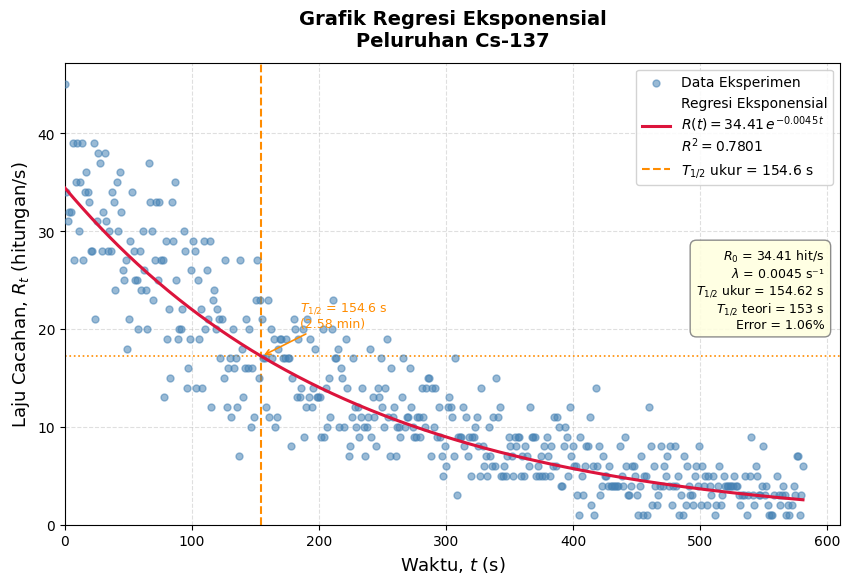

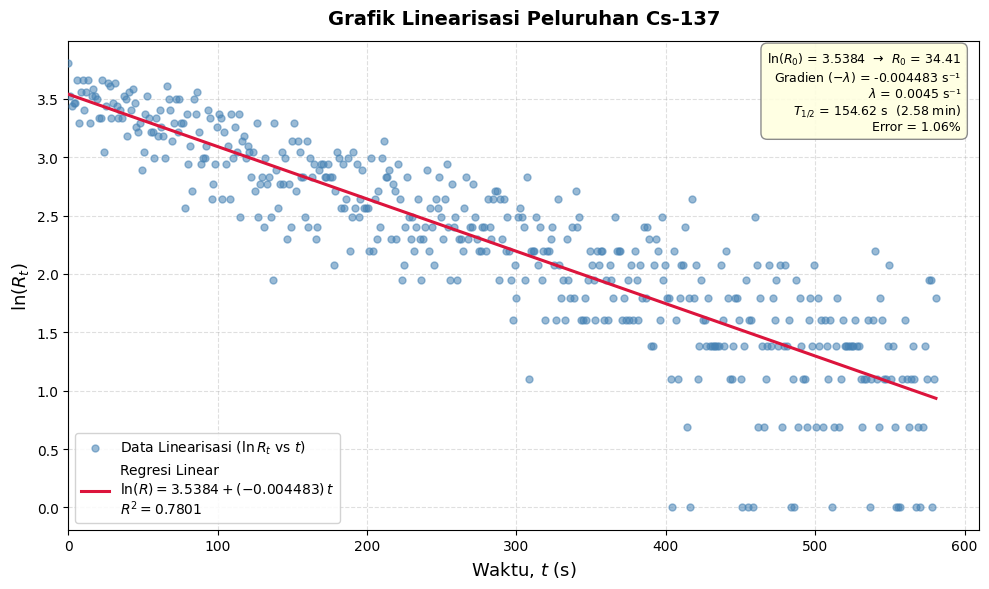

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from scipy.optimize import curve_fit
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)
print(f"   Jumlah baris: {len(df)}")
print(df.head())

t_raw = df.iloc[:, 0].values / 1000.0
R_all = df.iloc[:, 1].values

idx_peak = np.argmax(R_all)
t0 = t_raw[idx_peak]

print(f"Puncak aktivitas: R = {R_all[idx_peak]} hit/s  pada t_raw = {t0:.3f} s")
print(f"→ Waktu direset ke 0 mulai dari titik puncak (index {idx_peak})")

t = t_raw[idx_peak:] - t0
R = R_all[idx_peak:]

mask = R > 0
t_v = t[mask]
R_v = R[mask]
ln_R = np.log(R_v)

print(f"\nJumlah titik data valid (R > 0): {len(t_v)}")
print(f"Rentang waktu: {t_v[0]:.2f} s  –  {t_v[-1]:.2f} s")
print(f"Rentang aktivitas: {R_v.min():.0f}  –  {R_v.max():.0f} hit/s")

slope, intercept, r_val, p_val, std_err = stats.linregress(t_v, ln_R)

lambda_exp  = -slope
R0_lin      = np.exp(intercept)
T_half_exp  = np.log(2) / lambda_exp
T_half_teo  = 153.0
error_pct   = abs(T_half_teo - T_half_exp) / T_half_teo * 100
R2          = r_val**2

print("=" * 50)
print("  HASIL REGRESI LINEARISASI")
print("=" * 50)
print(f"  Persamaan : ln(R) = {intercept:.4f} + ({slope:.6f})·t")
print(f"  ln(R₀)    = {intercept:.4f}  →  R₀ = {R0_lin:.3f} hit/s")
print(f"  slope (−λ) = {slope:.6f} s⁻¹")
print(f"  λ ukur    = {lambda_exp:.6f} s⁻¹")
print(f"  T½ ukur   = ln(2) / {lambda_exp:.6f} = {T_half_exp:.2f} s  ({T_half_exp/60:.3f} menit)")
print(f"  T½ teori  = {T_half_teo:.0f} s  ({T_half_teo/60:.2f} menit)")
print(f"  Error     = {error_pct:.2f} %")
print(f"  R²        = {R2:.4f}")
print("=" * 50)

t_fit = np.linspace(t_v[0], t_v[-1], 500)
R_fit = R0_lin * np.exp(-lambda_exp * t_fit)

lnR_fit = intercept + slope * t_fit

fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.scatter(t_v, R_v,
            color='steelblue', s=25, alpha=0.55, zorder=3,
            label='Data Eksperimen')

ax1.plot(t_fit, R_fit,
         color='crimson', linewidth=2.2, zorder=4,
         label=(f'Regresi Eksponensial\n'
                f'$R(t) = {R0_lin:.2f}\\,e^{{-{lambda_exp:.4f}\\,t}}$\n'
                f'$R^2 = {R2:.4f}$'))

ax1.axvline(x=T_half_exp, color='darkorange', linestyle='--', linewidth=1.5,
            label=f'$T_{{1/2}}$ ukur = {T_half_exp:.1f} s')
ax1.axhline(y=R0_lin/2, color='darkorange', linestyle=':', linewidth=1.2)

ax1.annotate(f'$T_{{1/2}}$ = {T_half_exp:.1f} s\n({T_half_exp/60:.2f} min)',
             xy=(T_half_exp, R0_lin/2),
             xytext=(T_half_exp + 30, R0_lin/2 + 3),
             fontsize=9, color='darkorange',
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2))

ax1.set_xlabel('Waktu, $t$ (s)', fontsize=13)
ax1.set_ylabel('Laju Cacahan, $R_t$ (hitungan/s)', fontsize=13)
ax1.set_title('Grafik Regresi Eksponensial\nPeluruhan Cs-137',
              fontsize=14, fontweight='bold', pad=12)
ax1.legend(fontsize=10, loc='upper right', framealpha=0.85)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

info_text = (f"$R_0$ = {R0_lin:.2f} hit/s\n"
             f"$\\lambda$ = {lambda_exp:.4f} s⁻¹\n"
             f"$T_{{1/2}}$ ukur = {T_half_exp:.2f} s\n"
             f"$T_{{1/2}}$ teori = {T_half_teo:.0f} s\n"
             f"Error = {error_pct:.2f}%")
ax1.text(0.98, 0.60, info_text,
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.9))

fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.scatter(t_v, ln_R,
            color='steelblue', s=25, alpha=0.55, zorder=3,
            label='Data Linearisasi ($\\ln R_t$ vs $t$)')

ax2.plot(t_fit, lnR_fit,
         color='crimson', linewidth=2.2, zorder=4,
         label=(f'Regresi Linear\n'
                f'$\\ln(R) = {intercept:.4f} + ({slope:.6f})\\,t$\n'
                f'$R^2 = {R2:.4f}$'))

ax2.set_xlabel('Waktu, $t$ (s)', fontsize=13)
ax2.set_ylabel('$\\ln(R_t)$', fontsize=13)
ax2.set_title('Grafik Linearisasi Peluruhan Cs-137',
              fontsize=14, fontweight='bold', pad=12)
ax2.legend(fontsize=10, loc='lower left', framealpha=0.85)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_xlim(left=0)

info_text2 = (f"$\\ln(R_0)$ = {intercept:.4f}  →  $R_0$ = {R0_lin:.2f}\n"
              f"Gradien ($-\\lambda$) = {slope:.6f} s⁻¹\n"
              f"$\\lambda$ = {lambda_exp:.4f} s⁻¹\n"
              f"$T_{{1/2}}$ = {T_half_exp:.2f} s  ({T_half_exp/60:.2f} min)\n"
              f"Error = {error_pct:.2f}%")
ax2.text(0.98, 0.98, info_text2,
         transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('grafik_linearisasi.png', dpi=200, bbox_inches='tight')
plt.show()

Tanpa Halangan: y = 3.7764 * exp(-0.0693 * x)
Kertas HVS: y = 2.5811 * exp(-0.0752 * x)
Aluminium Foil: y = 1.0000 * exp(0.0000 * x)


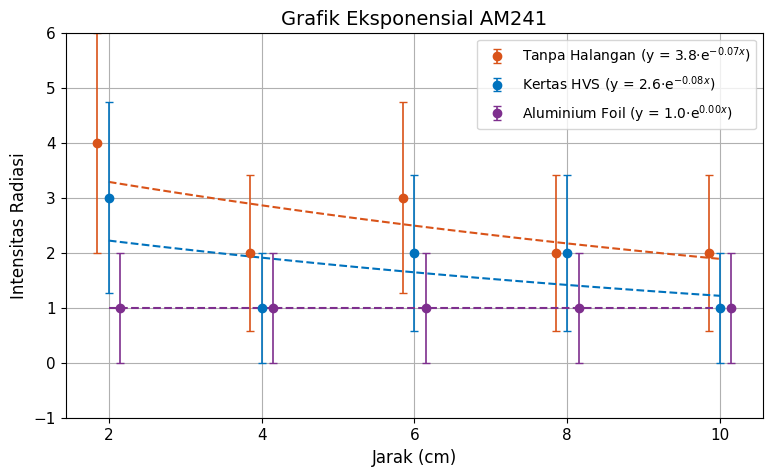

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10])

y_tanpa  = np.array([4, 2, 3, 2, 2], dtype=float)
y_kertas = np.array([3, 1, 2, 2, 1], dtype=float)
y_alum   = np.array([1, 1, 1, 1, 1], dtype=float)

datasets = [y_tanpa, y_kertas, y_alum]
labels   = ['Tanpa Halangan', 'Kertas HVS', 'Aluminium Foil']
colors   = ['#D95319', '#0072BD', '#7E2F8E']
offsets  = [-0.15, 0, 0.15]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_smooth = np.linspace(2, 10, 100)

for i, (yi, label, color, offset) in enumerate(zip(datasets, labels, colors, offsets)):

    y_for_fit = yi.copy()
    y_for_fit[y_for_fit == 0] = 0.05

    p = np.polyfit(x, np.log(y_for_fit), 1)
    b = p[0]
    a = np.exp(p[1])

    print(f"{label}: y = {a:.4f} * exp({b:.4f} * x)")

    y_smooth = a * np.exp(b * x_smooth)
    ax.plot(x_smooth, y_smooth, '--', color=color, linewidth=1.5)

    ei = np.sqrt(yi)
    ei[yi == 0] = 0.5

    ax.errorbar(
        x + offset, yi, yerr=ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (y = {a:.1f}·e$^{{{b:.2f}x}}$)'
    )

ax.set_xlabel('Jarak (cm)', fontsize=12)
ax.set_ylabel('Intensitas Radiasi', fontsize=12)
ax.set_title('Grafik Eksponensial AM241', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(-1, y_tanpa.max() + 2)
ax.tick_params(labelsize=11)

Tanpa Halangan: Y = -0.0693x + 1.3288
Kertas HVS: Y = -0.0752x + 0.9482
Aluminium Foil: Y = 0.0000x + 0.0000


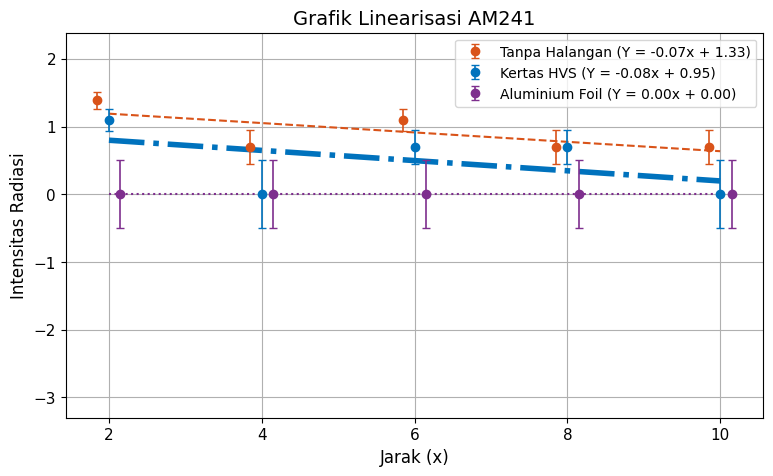

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10], dtype=float)

y_tanpa  = np.array([4, 2, 3, 2, 2], dtype=float)
y_kertas = np.array([3, 1, 2, 2, 1], dtype=float)
y_alum   = np.array([1, 1, 1, 1, 1], dtype=float)

datasets    = [y_tanpa, y_kertas, y_alum]
labels      = ['Tanpa Halangan', 'Kertas HVS', 'Aluminium Foil']
colors      = ['#D95319', '#0072BD', '#7E2F8E']
line_styles = ['--', '-.', ':']
line_widths = [1.5, 4.0, 1.5]
offsets     = [-0.15, 0, 0.15]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_fit = np.linspace(x.min(), x.max(), 100)

for yi, label, color, ls, lw, offset in zip(
        datasets, labels, colors, line_styles, line_widths, offsets):

    y_linear = yi.copy()
    y_linear[y_linear == 0] = 0.1
    Yi = np.log(y_linear)

    p = np.polyfit(x, Yi, 1)
    m, c = p[0], p[1]

    print(f"{label}: Y = {m:.4f}x + {c:.4f}")

    Y_fit = m * x_fit + c
    ax.plot(x_fit, Y_fit, ls, color=color, linewidth=lw)

    ei = 0.5 / y_linear

    ax.errorbar(
        x + offset, Yi, yerr=ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (Y = {m:.2f}x + {c:.2f})'
    )

ax.set_xlabel('Jarak (x)', fontsize=12)
ax.set_ylabel('Intensitas Radiasi', fontsize=12)
ax.set_title('Grafik Linearisasi AM241', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(np.log(0.1) - 1, np.log(4) + 1)
ax.tick_params(labelsize=11)

Tanpa Halangan: y = 17.58 * exp(-0.18 * x)
Sylinc: y = 12.64 * exp(-0.19 * x)
Aluminium Foil: y = 12.27 * exp(-0.24 * x)


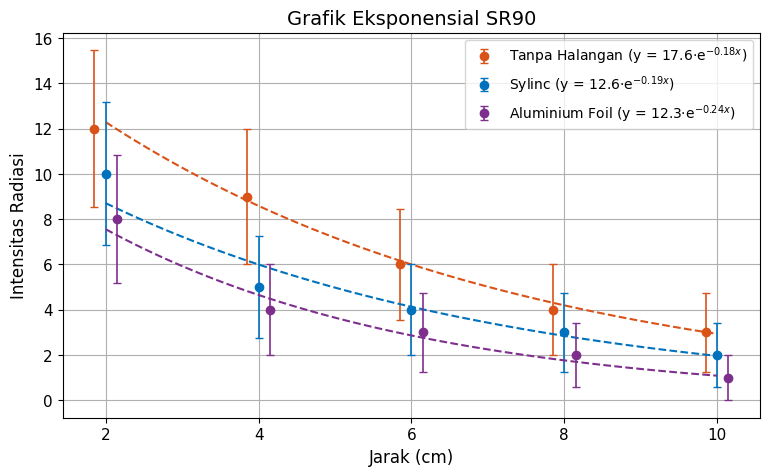

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10], dtype=float)

y_tanpa  = np.array([12, 9, 6, 4, 3], dtype=float)
y_kertas = np.array([10, 5, 4, 3, 2], dtype=float)
y_alum   = np.array([8, 4, 3, 2, 1], dtype=float)

datasets = [y_tanpa,  y_kertas, y_alum]
labels   = ['Tanpa Halangan', 'Sylinc', 'Aluminium Foil']
colors   = ['#D95319', '#0072BD', '#7E2F8E']
offsets  = [-0.15, 0, 0.15]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_fit = np.linspace(x.min(), x.max(), 100)

for yi, label, color, offset in zip(datasets, labels, colors, offsets):

    ei = np.sqrt(yi)

    p = np.polyfit(x, np.log(yi), 1)
    b = p[0]
    a = np.exp(p[1])

    print(f"{label}: y = {a:.2f} * exp({b:.2f} * x)")

    ax.errorbar(
        x + offset, yi, yerr=ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (y = {a:.1f}·e$^{{{b:.2f}x}}$)'
    )

    ax.plot(x_fit, a * np.exp(b * x_fit), '--', color=color, linewidth=1.5)

ax.set_xlabel('Jarak (cm)', fontsize=12)
ax.set_ylabel('Intensitas Radiasi', fontsize=12)
ax.set_title('Grafik Eksponensial SR90', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(labelsize=11)

Tanpa Halangan: Y = -0.1792*x + 2.8668
Sylinc: Y = -0.1865*x + 2.5369
Aluminium Foil: Y = -0.2426*x + 2.5071


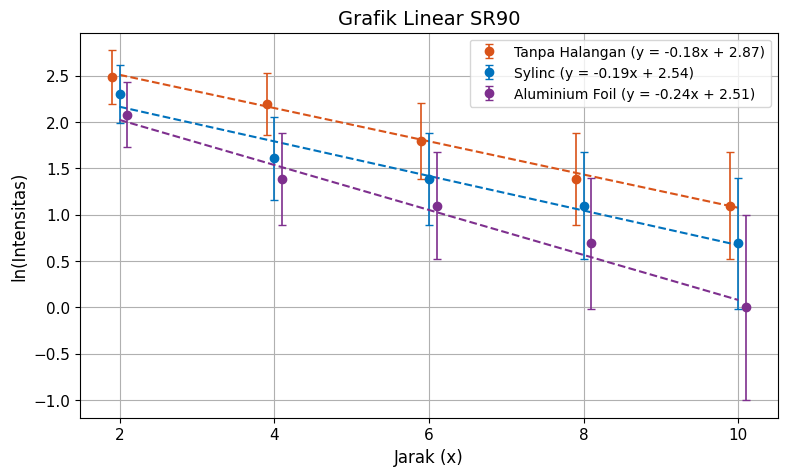

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10], dtype=float)

y_tanpa  = np.array([12, 9, 6, 4, 3], dtype=float)
y_sylinc = np.array([10, 5, 4, 3, 2], dtype=float)
y_alum   = np.array([8, 4, 3, 2, 1], dtype=float)

ln_y_tanpa  = np.log(y_tanpa)
ln_y_kertas = np.log(y_sylinc)
ln_y_alum   = np.log(y_alum)

err_tanpa  = 1 / np.sqrt(y_tanpa)
err_kertas = 1 / np.sqrt(y_sylinc)
err_alum   = 1 / np.sqrt(y_alum)

datasets = [ln_y_tanpa,  ln_y_kertas,  ln_y_alum]
errsets  = [err_tanpa,   err_kertas,   err_alum]
labels   = ['Tanpa Halangan', 'Sylinc', 'Aluminium Foil']
colors   = ['#D95319', '#0072BD', '#7E2F8E']
offsets  = [-0.1, 0, 0.1]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_fit = np.linspace(x.min(), x.max(), 100)

for Yi, Ei, label, color, offset in zip(
        datasets, errsets, labels, colors, offsets):

    p = np.polyfit(x, Yi, 1)
    m, c = p[0], p[1]

    print(f"{label}: Y = {m:.4f}*x + {c:.4f}")

    ax.errorbar(
        x + offset, Yi, yerr=Ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (y = {m:.2f}x + {c:.2f})'
    )

    ax.plot(x_fit, m * x_fit + c, '--', color=color, linewidth=1.5)

ax.set_xlabel('Jarak (x)', fontsize=12)
ax.set_ylabel('ln(Intensitas)', fontsize=12)
ax.set_title('Grafik Linear SR90', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(labelsize=11)

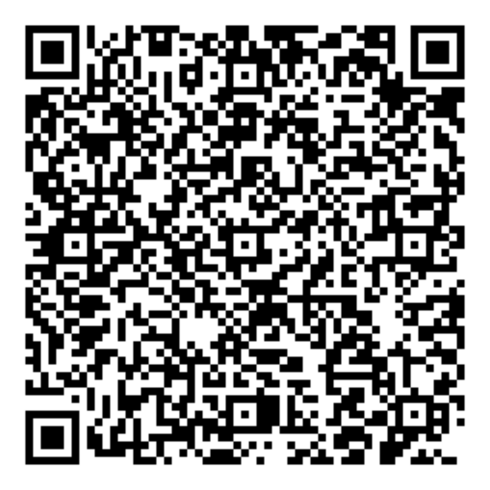

In [ ]:
!pip install qrcode[pil] -q

import qrcode
import matplotlib.pyplot as plt

data = "https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP4_RADIOAKTIVITAS1.ipynb"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=3,
    border=2,
)
qr.add_data(data)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()